In [1]:
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
dfs = []
for i in range(1, 25):
    dfs.append(pd.read_csv(f'../metrics/results_{i}_steps.csv', delimiter=';', quotechar='"'))

df = pd.concat(dfs, ignore_index=True)

In [3]:
df

,autoregression_steps,metric,mean/std,variable,level,lat_weighted,value
0,1,mae,mean,all,-1,False,0.056009
1,1,mae,std,all,-1,False,0.008395
2,1,mse,mean,all,-1,False,0.006866
3,1,mse,std,all,-1,False,0.001694
4,1,rmse,mean,all,-1,False,0.082191
...,...,...,...,...,...,...,...
10363,24,mae,std,geopotential,4,True,0.004676
10364,24,mse,mean,geopotential,4,True,0.002240
10365,24,mse,std,geopotential,4,True,0.000775
10366,24,rmse,mean,geopotential,4,True,0.046584


In [4]:
over_all_vars = df[df.variable == "all"]

means = over_all_vars[over_all_vars["mean/std"] == "mean"]
lat_means = means[means.lat_weighted == True]
means = means[means.lat_weighted == False]
lat_means = lat_means.drop(["mean/std", "lat_weighted", "variable", "level"], axis=1)
means = means.drop(["mean/std", "lat_weighted", "variable", "level"], axis=1)
lat_means = lat_means.rename(columns={'value': 'mean'})
means = means.rename(columns={'value': 'mean'})

stds = over_all_vars[over_all_vars["mean/std"] == "std"]
lat_stds = stds[stds.lat_weighted == True]
stds = stds[stds.lat_weighted == False]
lat_stds = lat_stds.drop(["mean/std", "lat_weighted", "variable", "level"], axis=1)
stds = stds.drop(["mean/std", "lat_weighted", "variable", "level"], axis=1)
lat_stds = lat_stds.rename(columns={'value': 'std'})
stds = stds.rename(columns={'value': 'std'})

mean_over_vars = pd.merge(means, stds, on=['autoregression_steps', 'metric'])
mean_over_vars_lat = pd.merge(lat_means, lat_stds, on=['autoregression_steps', 'metric'])

In [5]:
metric_colors = {'mae': 'blue', 'mse': 'green', 'rmse': 'red'}


def plot_mean_std(df):
    plt.figure(figsize=(10, 6))

    for metric in df['metric'].unique():
        metric_data = df[df['metric'] == metric]
        plt.plot(
            metric_data['autoregression_steps'],
            metric_data['mean'],
            label=metric,
            color=metric_colors[metric]
        )
        plt.fill_between(
            metric_data['autoregression_steps'],
            metric_data['mean'] - metric_data['std'],
            metric_data['mean'] + metric_data['std'],
            color=metric_colors[metric],
            alpha=0.2
        )

    plt.title('Fehlerkennzahlen über autoregressive Schritte')
    plt.xlabel('Autoregressive Schritte')
    plt.ylabel('Fehler (Mittelwert ± Standardabweichung)')
    plt.legend(title='Metrik')
    plt.grid(True)
    plt.show()


variable_colors = {}


def plot_variable_data(df):
    """
    Plots data for each variable with separate lines and error bands.

    Parameters:
    df (DataFrame): The DataFrame containing the data. It should have columns:
        'variable', 'autoregression_steps', 'mean', and 'std'.
    variable_colors (dict): A dictionary mapping each variable to a color.
    """
    plt.figure(figsize=(10, 6))

    for variable in df['variable'].unique():
        variable_data = df[df['variable'] == variable]
        plt.plot(
            variable_data['autoregression_steps'],
            variable_data['mean'],
            label=variable,
            color=variable_colors.get(variable, 'black')  # Default to 'black' if no color specified
        )
        plt.fill_between(
            variable_data['autoregression_steps'],
            variable_data['mean'] - variable_data['std'],
            variable_data['mean'] + variable_data['std'],
            color=variable_colors.get(variable, 'black'),
            alpha=0.2
        )

    plt.title('Daten pro Variable über autoregressive Schritte')
    plt.xlabel('Autoregressive Schritte')
    plt.ylabel('Datenwert (Mittelwert ± Standardabweichung)')
    plt.legend(title='Variable')
    plt.grid(True)
    plt.show()

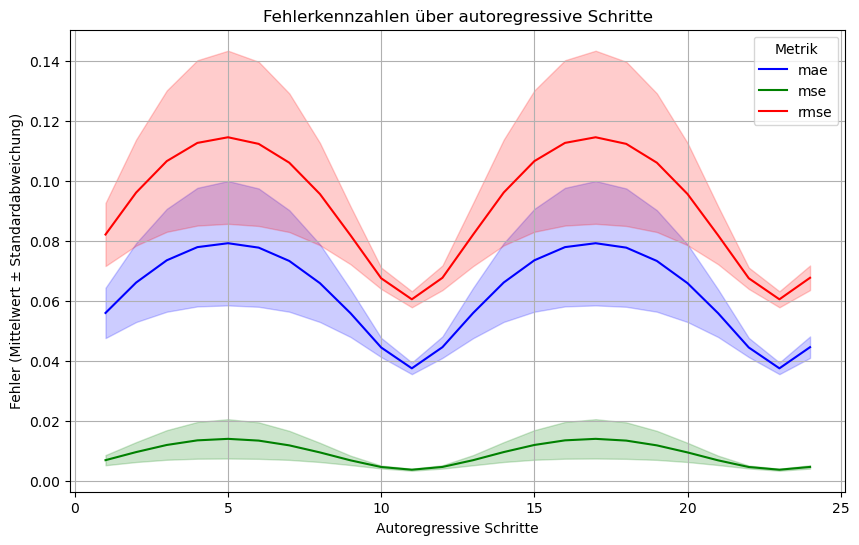

In [6]:
plot_mean_std(mean_over_vars)

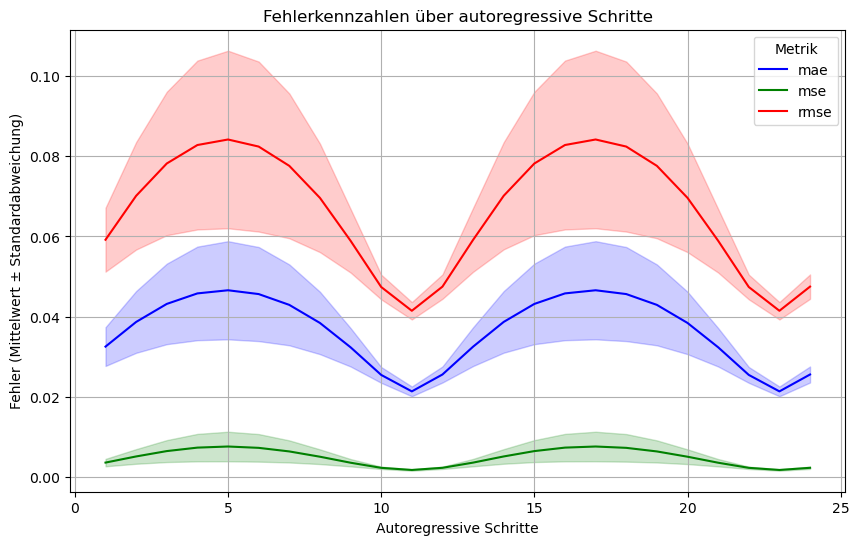

In [7]:
plot_mean_std(mean_over_vars_lat)

In [8]:
over_vars = df[df.variable != "all"]
over_vars = over_vars.pivot_table(
    index=["autoregression_steps", "metric", "variable", "level", "lat_weighted"],
    columns="mean/std",
    values="value"
).reset_index()

level_vars = over_vars[over_vars.level >= 0]
surface_vars = over_vars[over_vars.level == -1]

mean/std  autoregression_steps metric             variable  level  \
6                            1    mae         geopotential      0   
7                            1    mae         geopotential      0   
24                           1    mae    specific_humidity      0   
25                           1    mae    specific_humidity      0   
36                           1    mae          temperature      0   
...                        ...    ...                  ...    ...   
5007                        24   rmse          temperature      0   
5018                        24   rmse  u_component_of_wind      0   
5019                        24   rmse  u_component_of_wind      0   
5028                        24   rmse  v_component_of_wind      0   
5029                        24   rmse  v_component_of_wind      0   

mean/std  lat_weighted      mean       std  
6                False  0.039462  0.008465  
7                 True  0.031554  0.006448  
24               False  0.065402  0.

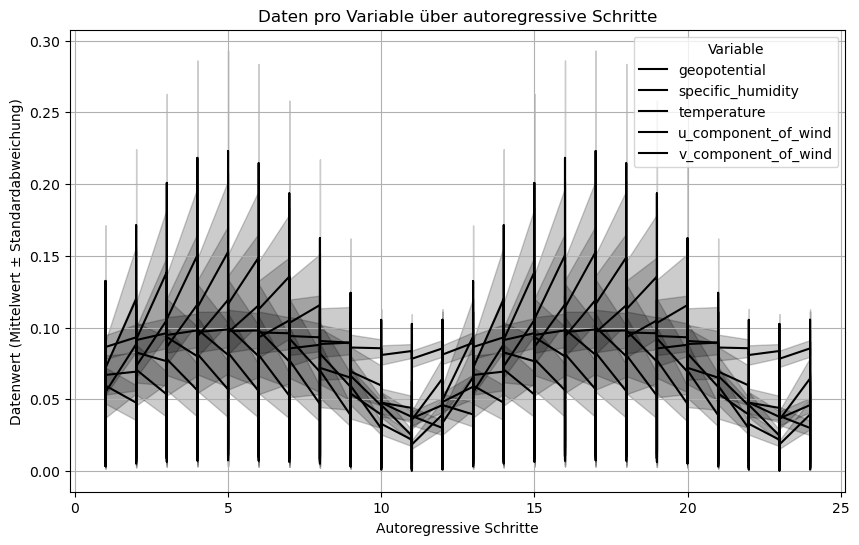

mean/std  autoregression_steps metric             variable  level  \
8                            1    mae         geopotential      1   
9                            1    mae         geopotential      1   
26                           1    mae    specific_humidity      1   
27                           1    mae    specific_humidity      1   
38                           1    mae          temperature      1   
...                        ...    ...                  ...    ...   
5009                        24   rmse          temperature      1   
5020                        24   rmse  u_component_of_wind      1   
5021                        24   rmse  u_component_of_wind      1   
5030                        24   rmse  v_component_of_wind      1   
5031                        24   rmse  v_component_of_wind      1   

mean/std  lat_weighted      mean       std  
8                False  0.046035  0.011096  
9                 True  0.036001  0.008047  
26               False  0.062649  0.

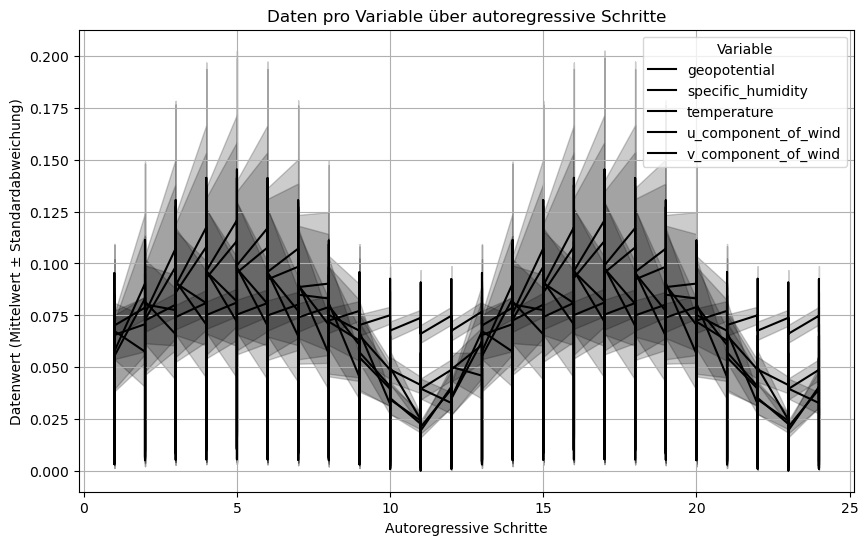

mean/std  autoregression_steps metric             variable  level  \
10                           1    mae         geopotential      2   
11                           1    mae         geopotential      2   
28                           1    mae    specific_humidity      2   
29                           1    mae    specific_humidity      2   
40                           1    mae          temperature      2   
...                        ...    ...                  ...    ...   
5011                        24   rmse          temperature      2   
5022                        24   rmse  u_component_of_wind      2   
5023                        24   rmse  u_component_of_wind      2   
5032                        24   rmse  v_component_of_wind      2   
5033                        24   rmse  v_component_of_wind      2   

mean/std  lat_weighted      mean       std  
10               False  0.047529  0.012203  
11                True  0.036931  0.008783  
28               False  0.055934  0.

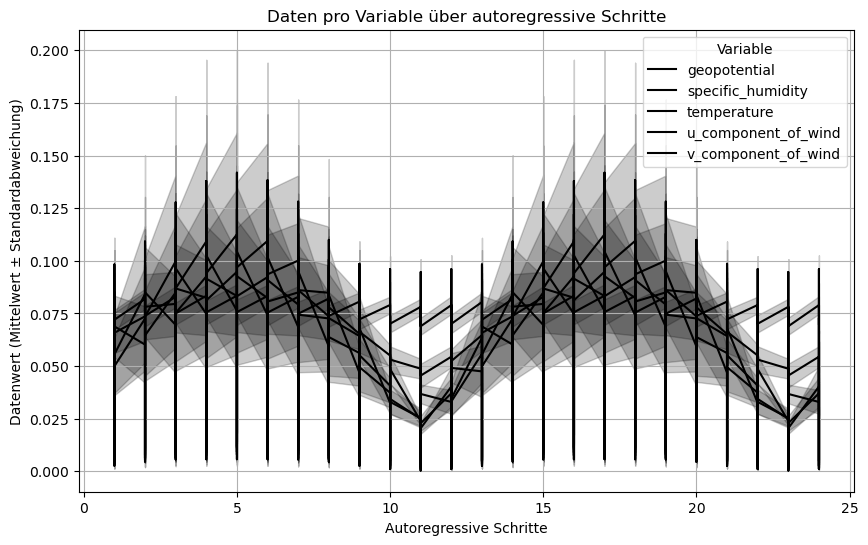

mean/std  autoregression_steps metric             variable  level  \
12                           1    mae         geopotential      3   
13                           1    mae         geopotential      3   
30                           1    mae    specific_humidity      3   
31                           1    mae    specific_humidity      3   
42                           1    mae          temperature      3   
...                        ...    ...                  ...    ...   
5013                        24   rmse          temperature      3   
5024                        24   rmse  u_component_of_wind      3   
5025                        24   rmse  u_component_of_wind      3   
5034                        24   rmse  v_component_of_wind      3   
5035                        24   rmse  v_component_of_wind      3   

mean/std  lat_weighted      mean       std  
12               False  0.061533  0.016862  
13                True  0.043024  0.010658  
30               False  0.047986  0.

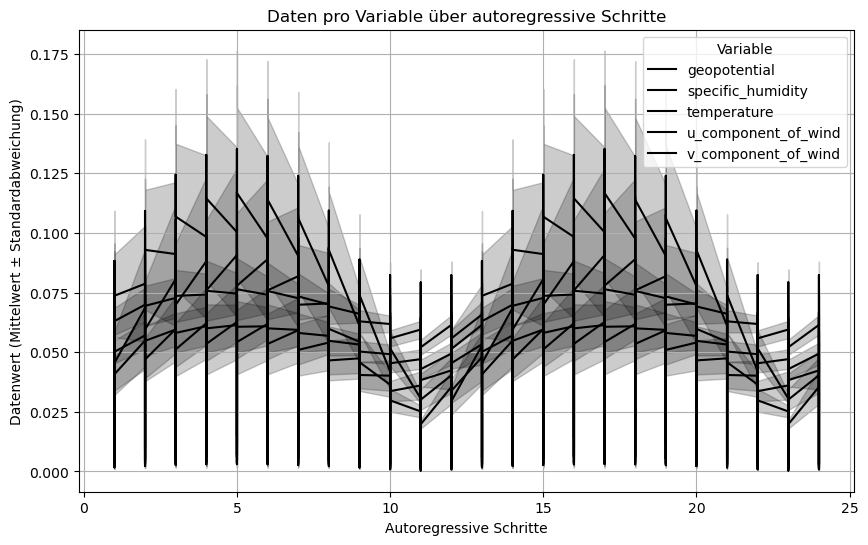

mean/std  autoregression_steps metric             variable  level  \
14                           1    mae         geopotential      4   
15                           1    mae         geopotential      4   
32                           1    mae    specific_humidity      4   
33                           1    mae    specific_humidity      4   
44                           1    mae          temperature      4   
...                        ...    ...                  ...    ...   
5015                        24   rmse          temperature      4   
5026                        24   rmse  u_component_of_wind      4   
5027                        24   rmse  u_component_of_wind      4   
5036                        24   rmse  v_component_of_wind      4   
5037                        24   rmse  v_component_of_wind      4   

mean/std  lat_weighted      mean       std  
14               False  0.058405  0.016593  
15                True  0.039281  0.010837  
32               False  0.048325  0.

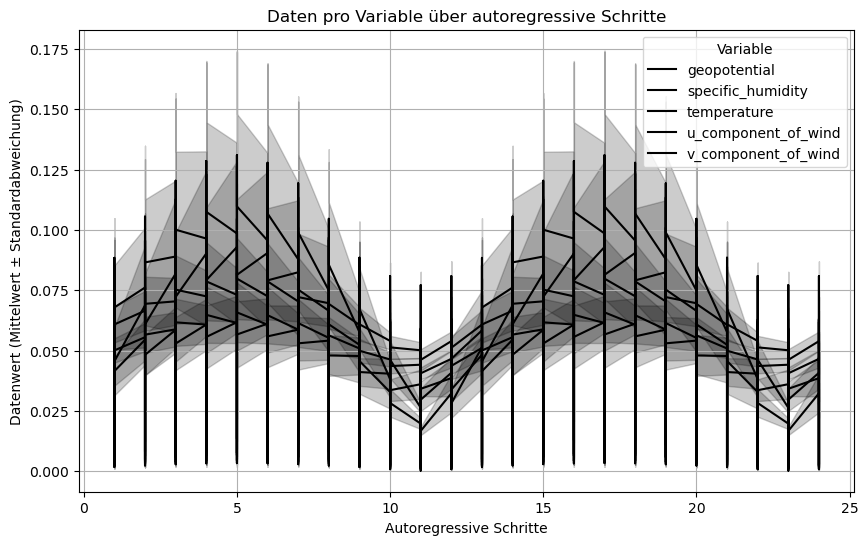

In [9]:
for level in set(level_vars.level):
    plot_df = level_vars[level_vars.level == level]
    print(plot_df)
    plot_variable_data(plot_df)